In [1]:
import numpy as np
import scipy
import time
import math
import itertools
from scipy.stats import norm

import mystic
from mystic.solvers import DifferentialEvolutionSolver, diffev2
from mystic.strategy import Best1Bin
from mystic.monitors import Monitor,VerboseMonitor

from copy import deepcopy

from tomography import *

from NestedForLoop import get_iterator
from pathlib import Path
from scipy.linalg import sqrtm

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import os
import glob

import pandas as pd

from scipy.optimize import least_squares

import fnmatch
from efficiencies import finding_file, get_channels_eff, set_raw_counts, set_raw_counts_double_emissions
from optimization import *
from constants import *
from densitymatrix import DensityMatrix, apply_unitary_to_dm

from pathlib import Path
import fnmatch

In [2]:
working_dir = os.getcwd()
# os.getcwd()+'\StateTomoData'
working_dir_data = r"C:\Users\QILIP6\Desktop\Multipartite Entanglement Experiment\Data\\QST"
#working_dir_data = r"C:\Users\QILIP6\Desktop\Multipartite Entanglement Experiment\Data\FOR PUBLICATION\GHZ_paper\Temporal multiplexer\No multiplexing"
# file="QST_Double_Layer_20250202194902"

In [3]:
######################################################################################################
#----- COUNTING THE FILES AND SAVING THEM IN AN ARRAY TO MAKES THE REST OF THE ANALYSIS EASIER -------
######################################################################################################

n_files=0
os.chdir(working_dir_data)

filenames = ['QST_Double_Layer_20251216161319']
filenames.sort(key=os.path.getmtime)
index_to_file = {}
print(filenames)

for index, filename in enumerate(filenames):
    os.chdir(f"{working_dir_data}\\{filename}")
    filenames_aux=[i for i in glob.glob("counts*")]
    for index_second, filenames_aux_second in enumerate(filenames_aux):
        index_to_file[n_files] = f"{filename}\\{filenames_aux_second}"
        n_files+=1
os.chdir(working_dir)
print("Analyse Files: ", filenames_aux)

['QST_Double_Layer_20251216161319']
Analyse Files:  ['counts']


In [4]:
#####################################################################
#---------------------- DEFINING PARAMS ----------------------------#
#####################################################################
os.chdir(working_dir)
qubit_number=2

## Defining the columns of the data file we want to use as data to reconstruct the density matrix (eg.: HH HV VH and VV basis)
BASIS_TO_CHANNEL={
    "HA": 1,
    "VA": 2,
    "HB": 3,
    "VB": 4,
    "HC": 5,
    "VC": 6,
    "HD": 7,
    "VD": 8,
    }

### Bell state ###
eigenstates = [['HA','HB'],['HA','VB'],['VA','HB'],['VA','VB']]

fold = four_fold=[[BASIS_TO_CHANNEL[eigenstates[i][j]] for j in range(qubit_number)] for i in range(len(eigenstates))]

In [5]:
datafile_channels = fold.copy()

for clicks in fold:
    not_in_clicks = list(set(range(1, 2*qubit_number+1)) - set(clicks))
    not_in_clicks.sort()
    for rep in range(1, len(not_in_clicks)+1):
        for combo in itertools.combinations(not_in_clicks, rep):
            new_clicks = clicks + list(combo)
            new_clicks.sort()
            datafile_channels.append(new_clicks)
            
datafile_channels = np.array(list(set(map(tuple, datafile_channels))), dtype=object)
first_order = list(map(len, datafile_channels)) 
order = np.lexsort((datafile_channels, first_order))
datafile_channels = list(datafile_channels[order])
datafile_channels = [list(t) for t in datafile_channels]

In [6]:
single_channels_offset = 0
coincidences_columns = []
double_emission_columns = []

for i, iter in enumerate(eigenstates):
    proj = [BASIS_TO_CHANNEL[iter[m]] for m in range(qubit_number)]
    coincidences_columns.append(datafile_channels.index(proj))
    double_emission_columns.append([datafile_channels.index(d) for d in datafile_channels if set(proj).issubset(set(d))])
    double_emission_columns[-1].remove(coincidences_columns[-1])

column_start = np.min(coincidences_columns) + single_channels_offset
column_stop = np.max(coincidences_columns) + 1 + single_channels_offset
print("Coincidences column_start:", column_start,"; column_stop: ", column_stop)

### NEED TO UPDATE IF ANALYSING A FILE BEFORE 03/01/2024 (to 8 - 12 and 13 - 17)

column_start_2_emissions = np.min(double_emission_columns) + 4 + single_channels_offset
column_stop_2_emissions = np.max(double_emission_columns) + 4 + single_channels_offset 
print("Double emission column_start:", column_start_2_emissions, "; column_stop: ", column_stop_2_emissions)

### NEED TO UPDATE IF ANALYSING A FILE BEFORE 03/01/2024 (to 12 - 13 and 17 - 18)

if single_channels_offset == 0: 

    column_start_4_emissions = 16 
    column_stop_4_emissions = 17
    print("Four emission column_start:", column_start_4_emissions, "; column_stop: ", column_stop_4_emissions)
else : 

    column_start_4_emissions = 17
    column_stop_4_emissions = 18
    print("Four emission column_start:", column_start_4_emissions, "; column_stop: ", column_stop_4_emissions)


Coincidences column_start: 0 ; column_stop:  4
Double emission column_start: 8 ; column_stop:  12
Four emission column_start: 16 ; column_stop:  17


In [7]:
statetomo = []
state = []
state_file = []

xp_counts_corrected_with_eff=[]
total_per_basis_list=[]

#####################################################################
#---------------------- STATE TOMOGRAPHY ----------------------------
#####################################################################
for index in range(len(index_to_file)):
    os.chdir(f"{working_dir_data}\\{index_to_file[index]}\\")
    datafiles=[i for i in glob.glob("*")]
    
    ### Calculating the efficiencies of each detector
    efficiencies=get_channels_eff(datafiles, qubit_number, column_start, column_stop, os.getcwd())
    efficiencies_2_emissions=get_channels_eff(datafiles, qubit_number, column_start_2_emissions, column_stop_2_emissions, os.getcwd())
    print("Channels efficiencies: ", efficiencies)
    print("Channels efficiencies (double emission): ", efficiencies_2_emissions)

    four_fold_efficiencies = efficiencies[0]*efficiencies[2]

    ### Opening the data files and writing the data in counts_aux array
    counts_aux=set_raw_counts(datafiles, qubit_number, column_start, column_stop, os.getcwd()) 
    xp_counts=np.array(np.transpose(counts_aux))
    total_per_basis_list.append(np.sum(xp_counts, axis=1))

    counts_aux_2_emissions=set_raw_counts(datafiles, qubit_number, column_start_2_emissions, column_stop_2_emissions, os.getcwd())
    xp_counts_2_emissions=np.array(np.transpose(counts_aux_2_emissions))

    counts_aux_4_emsissions= set_raw_counts_double_emissions(datafiles, qubit_number, column_start_4_emissions, column_stop_4_emissions, os.getcwd())
    xp_counts_4_emissions=np.array(np.round((np.transpose(counts_aux_4_emsissions))))

    statetomo.append(LRETomography(int(qubit_number), xp_counts ,xp_counts_2_emissions,xp_counts_4_emissions))
    statetomo[-1].run(correct_eff=efficiencies)
    xp_counts_corrected_with_eff.append(statetomo[-1].xp_counts)
        
    state.append(statetomo[-1])
    state_file.append(index_to_file[index])

Channels efficiencies:  [0.76882671 0.94888617 0.81096552 1.        ]
Channels efficiencies (double emission):  [0.85172673 1.         0.86411411 0.75938438]


In [18]:
######################################
#-- DEFINING THE TARGET BELL STATE ---
######################################
bell=(np.array([1,0,0,0])+np.array([0,0,0,1]))/np.sqrt(2)
bellmatrix=np.array(np.outer(bell, np.conjugate(bell)))
rho_target = bellmatrix
aq_time = 1 #in seconds
fidelity_list = []
rate_list = []

states=state
for index, file in enumerate(filenames):
    rate_list.append(np.round(np.average(total_per_basis_list[index])/aq_time,2))
    fidelity_list.append(np.real(np.round(states[index].state.fidelity(bell),5)))
print(rate_list)
print(fidelity_list)

[3742872.67]
[0.31751]


In [19]:
##########################################################
#------------ PLOTTING RAW DENSITY MATRIX----------------#
##########################################################
# statetomo[-1].state.plot_dm()

In [20]:
##########################################################
#----- OPTIMIZATION OF MAX FIDELITY UP TO UNITARIES ------
##########################################################
states=state
fid=np.zeros((n_files))
optimized_matrix=np.zeros((n_files,2**qubit_number,2**qubit_number), dtype='complex')

guess=np.zeros(6*(qubit_number-1))
bounds=[(-np.pi,np.pi)]*6*(qubit_number-1)
results = []
guess[0] = np.pi/8
opt=Optimizer(guess, function_fidelity_U2, results=FidelityResults)
for index in range(len(states)):
    result=opt.optimize_fmin(qubit_number,states[index].state, bell, bounds=bounds)
    results.append(result)

In [21]:
##########################################################
#------------ ERRORS Input with BELL STATE---------------#
##########################################################
error_runs=1

U=[]
bell_aux=[]
target_ini=[]

states=state
states_file=state_file
players=["Arya", "Bran","Cersei","Dany"]

for index in range(len(states)):
    target=bellmatrix
    U.append(results[index].u)
    target_ini.append(np.transpose(np.conjugate(U[-1]))@bellmatrix@U[-1])    
    states[index].calculate_fidelity_error(players, error_runs, opt, target, optimization=True, bounds=bounds)
    
    print('file, fidelity, fidelity_mean, fidelity_std: ',
          states_file[index], np.round(states[index].state.fidelity(target_ini[-1]),5), -np.round(states[index].fidelity_mu,5),
          np.round(states[index].fidelity_std,5), '\n')

Simulating new states considering the uncertainties
Optimizing the fidelity between input and target up to a unitary
file, fidelity, fidelity_mean, fidelity_std:  QST_Double_Layer_20251216161319\counts (0.99125-0j) 0.99076 0.0 



In [132]:
print(repr(np.array(results[-1].u1)))
print(repr(np.array(results[-1].u2)))

array([[ 0.75761129-0.2108463j ,  0.42480686+0.44845078j],
       [-0.42480686+0.44845078j,  0.75761129+0.2108463j ]])
array([[ 0.9476473 -0.13602484j, -0.28877142-0.00853877j],
       [ 0.28877142-0.00853877j,  0.9476473 +0.13602484j]])


In [17]:
##########################################################
#------- PLOTTING OPTIMIZED DENSITY MATRIX------------#
##########################################################
print(f"filename: {file}")
aq_time=1#in seconds
print(f"Average Rate: ({np.average(total_per_basis_list[-1])/aq_time} +/- {np.std(total_per_basis_list[-1])/aq_time}) Hz")
print(f"Fidelity with unitary optimization = {np.round(states[index].state.fidelity(target_ini[-1]),5)}%")
print(f"Fidelity with no unitary optimization = {np.real(np.round(states[index].state.fidelity(bell),5))}%")
results[-1].optimized_state.plot_dm()

# print("Filename - no unitary optimization: ", file)
# aq_time=20 #in seconds
# print(f"Average Rate: ({np.average(total_per_basis)/aq_time} +/- {np.std(total_per_basis)/aq_time}) Hz")
# print(f"Fidelity with no unitary correction = {np.round(states[index].state.fidelity(bellmatrix),5)}%")
state[-1].state.plot_dm()

os.chdir(working_dir_data +'\\'+ filename)
print(working_dir_data +'\\'+ filename)
np.save("density_TOP.npy", state[-1].state.state, allow_pickle=True)


filename: QST_Double_Layer_20251216161319
Average Rate: (3742872.6666666665 +/- 22208.819279236293) Hz


NameError: name 'target_ini' is not defined

In [19]:
results[-1].optimized_state.state

array([[ 0.51099633+5.20417043e-18j,  0.00246478+1.16149399e-02j,
         0.00293553-1.19419412e-02j,  0.49471087+2.10482269e-10j],
       [ 0.00246478-1.16149399e-02j,  0.00169211+4.33680869e-18j,
        -0.00140048+9.13082365e-04j,  0.00394226-8.67063681e-03j],
       [ 0.00293553+1.19419412e-02j, -0.00140048-9.13082365e-04j,
         0.00197869+3.12250226e-17j,  0.00347152+8.34362751e-03j],
       [ 0.49471087-2.10482271e-10j,  0.00394226+8.67063681e-03j,
         0.00347152-8.34362751e-03j,  0.48533288-2.60208521e-17j]])

In [23]:
# np.save(r"C:\Users\Experience\Desktop\Multipartite Entanglement Experiment\Data\QST\dm_top.npy", results[-1].optimized_state.state)

In [20]:
print(results[-1].u1)
print(results[-1].u2)

[[ 0.96429046-0.25661038j  0.06439908+0.01215682j]
 [-0.06439908+0.01215682j  0.96429046+0.25661038j]]
[[ 0.6033729-0.41500882j  0.6466041+0.21356958j]
 [-0.6466041+0.21356958j  0.6033729+0.41500882j]]


In [ ]:
### Finding the rotation in z needed to arrive at the desired Bell state
results[0].params[0]

# def z_rotation(x):
#     return np.array([[np.exp(-1j*x[0]/2), 0],
#                      [0, np.exp(1j*x[0]/2)]])

# z_rotation(results[0].params)

-0.007504857068556489

In [ ]:
#### Everything under this line was used to analyse the quantum transmission certification

In [ ]:
##########################################################
#--------------- ERRORS OUTPUT TO INTPUT ----------------#
##########################################################
U=[]
bell_aux=[]
target_ini=[]

states=state_before

for index in range(len(states)):
    target=state_after[index]
    U.append(np.kron(results[index].u1,results[index].u2))
    target_ini.append(np.transpose(np.conjugate(U[-1]))@state_after[index].state.state@U[-1])
    
    states[index].calculate_fidelity_error_between_2_experimental_matrices(error_runs, players, target, apply_unitary_to_input=True)
    
    print('file, fidelity, fidelity_mean, fidelity_std: ',
          state_after_file[index], np.round(states[index].state.fidelity(target_ini[-1]),5), -np.round(states[index].fidelity_2_experimental_dms_mu,5),
          np.round(states[index].fidelity_2_experimental_dms_std,5), "\n")

NameError: name 'state_before' is not defined

In [ ]:
bell=(np.array([0,1,0,0])-np.array([0,0,1,0]))/np.sqrt(2)
bellmatrix=np.array(np.outer(bell, np.conjugate(bell)))

result=opt.optimize(state_before[2].state, bell, bounds=bounds)
U[2]=np.kron(result.u1,result.u2)

t=state_after[2].state.state

t_ini=np.linalg.inv(U[2])@state_after[2].state.state@np.linalg.inv(np.transpose(np.conjugate(U[2])))

states[2].calculate_fidelity_error(players, error_runs, opt, t, bounds=bounds)

print('index, fidelity, fidelity_mean, fidelity_std: ',
        state_before_file[index], np.round(states[2].state.fidelity(t_ini),5), np.round(states[2].fidelity_mu,5),
        np.round(states[2].fidelity_std,5))

In [ ]:
##########################################################
#------------ ERRORS OUTPUT with BELL STATE--------------#
##########################################################
bell=(np.array([0,1,0,0])+np.array([0,0,1,0]))/np.sqrt(2)
bellmatrix=np.array(np.outer(bell, np.conjugate(bell)))
error_runs=30

U=[]
bell_aux=[]
target_ini=[]

states=state_after
players=["Arya", "Cersei"]

guess=np.array([0, 0, 0])
bounds=[(-np.pi,np.pi)]*3
opt=Optimizer(guess, function_fidelity, results=FidelityResults)

for index in range(len(states)):
    target=bellmatrix
    #U.append(results[index].u)
    #target_ini.append(np.transpose(np.conjugate(U[-1]))@bellmatrix@U[-1])    
    
    states[index].calculate_fidelity_error(players, error_runs, opt, target, bounds=bounds)
    
    print('index, fidelity, fidelity_mean, fidelity_std: ',
          state_after_file[index], np.round(states[index].state.fidelity(target),5), np.round(states[index].fidelity_mu,5),
          np.round(states[index].fidelity_std,5))

In [ ]:
bell=(np.array([0,1,0,0])-np.array([0,0,1,0]))/np.sqrt(2)
bellmatrix=np.array(np.outer(bell, np.conjugate(bell)))
target=bellmatrix

result=opt.optimize(state_before[2].state, bell, bounds=bounds)

t=state_after[2].state.state

states[2].calculate_fidelity_error(players, error_runs, opt, t, bounds=bounds)

print('index, fidelity, fidelity_mean, fidelity_std: ',
        state_after_file[index], np.round(states[2].state.fidelity(target),5), np.round(states[2].fidelity_mu,5),
        np.round(states[2].fidelity_std,5))

In [ ]:
##########################################################
#------------ WRITING THE DATA IN AN EXCEL ---------------
##########################################################

import xlsxwriter
states=state_before

workbook = xlsxwriter.Workbook('fidelities_to_ini_state_errors.xlsx') ### We should write this in another place
 
worksheet = workbook.add_worksheet()

worksheet.write('A1', 'Number')
worksheet.write('B1', 'Folder')
worksheet.write('C1', 'Fidelity')
worksheet.write('D1', 'Fidelity_mean')
worksheet.write('E1', 'Fidelity_uncertainty')

counter=0
for index in range(len(state_before)):
    
    worksheet.write('A'+str(counter+2), counter)
    worksheet.write('B'+str(counter+2), state_before_file[index])
    worksheet.write('C'+str(counter+2), np.real(np.round(states_final[index].fidelity(target[index]),5)))#np.round(states[index].fidelity_to_pure(bell),5)))
    worksheet.write('D'+str(counter+2), np.real(np.round(states_final[index].mu,5)))
    worksheet.write('E'+str(counter+2), np.real(np.round(states_final[index].std,5)))
    counter+=1
        
workbook.close()

In [ ]:
### IF WE WANT TO CHECK THE FIT TO THE UNCERTARTAINTY
### Then we need to calculate the statistic on these simulated fidelities and calculate the standart deviation
### This will be our uncertainty due to statistical errors
def count_elements(seq) -> dict:
    hist = {}
    for i in seq:
        hist[i] = hist.get(i, 0) + 1
    return hist

counted = count_elements(fidelity_sim)
#print(counted)
bin_numb = len(counted)
errorbar_x=np.array(list(counted))
errorbar_y=np.zeros((bin_numb), dtype=int)

for i in range(bin_numb):
    errorbar_y[i]=counted[errorbar_x[i]]
    
#print(errorbar_x)
#print(errorbar_y)
    
def Gauss(x, A, mu, sigm):
    y = A*np.exp(-((x-mu)/sigm)**2/2)
    return y

mu, std = norm.fit(fidelity_sim)
print(mu, std)
parameters, covariance = curve_fit(Gauss, xdata=errorbar_x[-1], ydata=errorbar_y[:-1], bounds=[(0,0.99007,1e-4),(60,0.9903,0.0002)])
fit_A = parameters[0]
fit_B = parameters[1]
fit_C = parameters[2]
print(fit_A, fit_B, fit_C)

xdata= x = np.linspace(0.989, 0.991, 100)
fit_y = Gauss(xdata, fit_A, fit_B, fit_C)
plt.plot(errorbar_x[:-1], errorbar_y[:-1], 'o', label='data')
plt.plot(xdata, fit_y, '-', label='fit')
plt.legend()

In [ ]:
### This was to analyse the quantum channel certification paper
# state_after=[]
# state_after_file=[]

# state_before=[]
# state_before_file=[]

## The 'e' and 'r' serve to distinguish between tomography before and after, respectively
    ## We want to save them in different arrays because we need them for different things
#     elif index_to_file[index][-8]=='e':
#         state_before.append(statetomo[-1])#.state)
#         state_before_file.append(index_to_file[index])
#         #print('\n Fast maximum likelihood estimation: \n', state_before[-1], '\n')

#     elif index_to_file[index][-8]=='r':
#         state_after.append(statetomo[-1])#.state)
#         state_after_file.append(index_to_file[index])
#         #print('\n Fast maximum likelihood estimation: \n', state_after[-1], '\n')

C:\Users\QILIP6\AppData\Local\Temp\ipykernel_41616\336979864.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapp = cm.ScalarMappable(cmap=cm.get_cmap("coolwarm"))


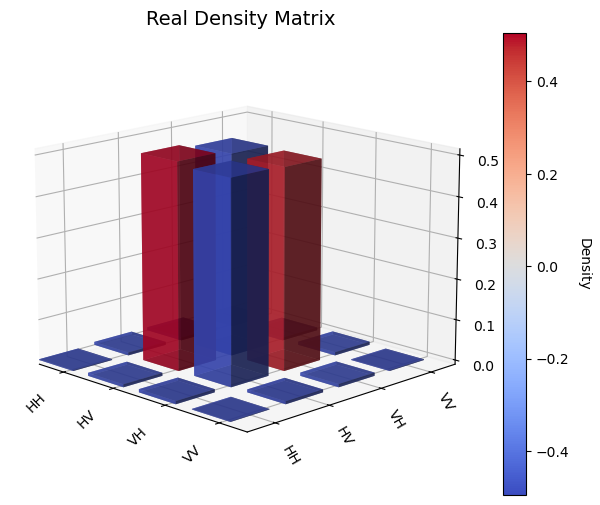

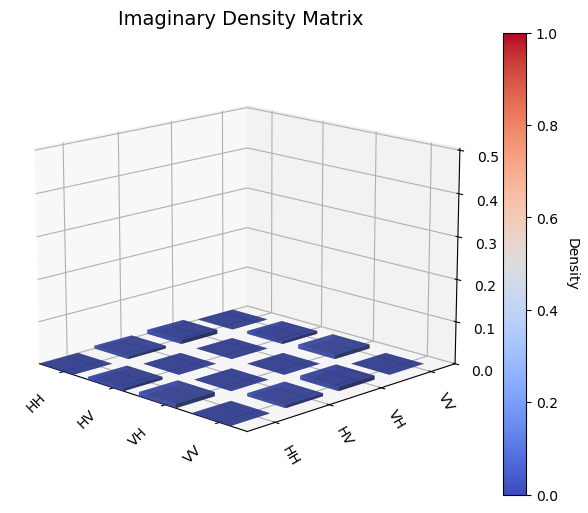

In [103]:
def plot_dm(density, cbar_real=True, cbar_im=True, save_pdf=None, save_svg=None):

    density_matrix_plot = density
    real_density_matrix = density_matrix_plot.real
    imag_density_matrix = density_matrix_plot.imag
    HV_label = {0: "H", 1: "V"}

    HV_iterator = get_iterator(2, 2)
    axes_labels = []
    for k in range(np.shape(density_matrix_plot)[0]):
        axes_labels.append("".join(tuple(map(HV_label.get, HV_iterator[k]))))

    nrows, ncols = density_matrix_plot.shape

    # Create a meshgrid for the x and y values
    x = np.arange(ncols)
    y = np.arange(nrows)
    X, Y = np.meshgrid(x, y)

    # Flatten the density matrix values
    Z = real_density_matrix.flatten()
    W = imag_density_matrix.flatten()

    # Set the column heights as Z values
    column_heights = np.abs(Z)
    column_heights2 = np.abs(W)

    # Set the column widths and depths
    column_width = column_depth = 0.7

    # Create the first figure
    fig1 = plt.figure(figsize=(8, 6))
    ax1 = fig1.add_subplot(111, projection="3d")

    # Plot the density matrix as 3D columns using a colormap
    mapp = cm.ScalarMappable(cmap=cm.get_cmap("coolwarm"))
    mapp.set_array(Z)
    cmap = mapp.get_cmap()
    ax1.bar3d(
        X.ravel(),
        Y.ravel(),
        np.zeros_like(Z),
        column_width,
        column_depth,
        column_heights,
        shade=True,
        color=cmap(Z/(np.max(Z))),
        alpha=0.7,
    )

    ax1.set_xticks(np.arange(ncols) + 0.5)
    ax1.set_yticks(np.arange(nrows) + 0.5)
    ax1.set_xticklabels(
        axes_labels, rotation=45, ha="right", fontsize=10, fontweight="normal"
    )
    ax1.set_yticklabels(axes_labels, rotation=-60, fontsize=10, fontweight="normal")

    # Set the title
    ax1.set_title("Real Density Matrix", fontsize=14, fontweight="normal")

    # Add a colorbar
    
    if cbar_real==True:
        cbar = fig1.colorbar(mapp, ax=ax1)
        cbar.set_label("Density", rotation=270, labelpad=15)

    # Adjust plot limits to avoid cutoff of tick labels
    ax1.set_xlim(0, ncols)
    ax1.set_ylim(0, nrows)
    ax1.view_init(elev=15, azim=-45)

    if save_pdf is not None:
        plt.savefig(save_pdf+"\\density_matrix_re.pdf")

    if save_svg is not None:
        plt.savefig(save_svg+"\\density_matrix_re.svg")

    # # Display the figures
    plt.show()

    ############################################################
    # Create the second figure
    fig2 = plt.figure(figsize=(8, 6))
    ax2 = fig2.add_subplot(111, projection="3d")

    # Plot the density matrix as 3D columns using a colormap
    ax2.bar3d(
        X.ravel(),
        Y.ravel(),
        np.zeros_like(W),
        column_width,
        column_depth,
        column_heights2,
        shade=True,
        color=cmap(W/(np.max(Z))),
        alpha=0.7
    )

    # Set the x and y axis labels
    ax2.set_xticks(np.arange(ncols) + 0.5)
    ax2.set_yticks(np.arange(nrows) + 0.5)
    ax2.set_xticklabels(
        axes_labels, rotation=45, ha="right", fontsize=10, fontweight="normal"
    )
    ax2.set_yticklabels(axes_labels, rotation=-60, fontsize=10, fontweight="normal")
    ax2.set_zlim(0, np.max([column_heights, column_heights2]))  # Set z-axis limits

    # Set the title
    ax2.set_title("Imaginary Density Matrix", fontsize=14, fontweight="normal")

    # Add a colorbar
    if cbar_im==True:
        cbar = fig2.colorbar(cm.ScalarMappable(cmap=cmap), ax=ax2)
        cbar.set_label("Density", rotation=270, labelpad=15)

    # Adjust plot limits to avoid cutoff of tick labels
    ax2.set_xlim(0, ncols)
    ax2.set_ylim(0, nrows)
    ax2.view_init(elev=15, azim=-45)

    if save_pdf is not None:
        plt.savefig(save_pdf+"\\density_matrix_im.pdf")

    if save_svg is not None:
        plt.savefig(save_svg+"\\density_matrix_im.svg")

    # # Display the figures
    plt.show()

plot_dm(rho_display)
